# Optimización secuencial con *surrogate*: cerrar el loop hacia el óptimo

**Caso (extiende el nb 04):** la misma reacción catalítica, pero ahora el objetivo
no es *aprender* la superficie con la mayor precisión (augmentación D/I-óptima),
sino **optimizar el resultado**: proponer, oleada tras oleada, las corridas que más
acercan al óptimo real.

Ese es el motor `intent="optimize"` de `doekit`: un **surrogate** (GP con *media a
priori = la superficie OLS que doekit ya ajusta*) + una **función de adquisición**
(EI/UCB/EHVI). A diferencia de una caja negra, conserva el *moat* de doekit:
**σ(x) calibrada y auditable** (parity/calibration) e **interpretabilidad** (la
tendencia polinómica sigue contando la historia).

> **learn** (D/I-óptimo, afinar el *modelo*) → **optimize** (surrogate + adquisición,
> mover el *resultado*). Un solo parámetro, no dos sistemas.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

import doekit as ed
from doekit import plotting
from doekit.assessment.surrogate import fit_surrogate

rng = np.random.default_rng(7)
plt.rcParams["figure.dpi"] = 110

# Factores activos del nb 04 (descartamos 'tiempo' tras el screening)
activos = {"temp": (20.0, 80.0), "pH": (3.0, 9.0), "cat": (0.1, 0.5)}
FACS = ed.as_factors(activos)
_enc = {f.name: f for f in FACS}
MODELO = ed.Model.full_quadratic(list(activos))
print("Factores activos:", list(activos))


Factores activos: ['temp', 'pH', 'cat']


## 1. La "verdad" del laboratorio (solo para *benchmark*)

Reusamos la superficie cuadrática del nb 04 (en espacio codificado `-1..+1`): temp
y pH tienen óptimo y **interactúan**, el catalizador tiene su propio óptimo. En un
experimento real esta función es desconocida; aquí la usamos para medir qué tan
cerca del óptimo llega el loop.


In [2]:
def _codificar(df):
    return np.column_stack([_enc[n].encode(df[n].to_numpy()) for n in activos])

BETA = dict(base=80.0, T=6.0, pH=5.0, C=4.0, TT=-8.0, pHpH=-7.0, CC=-5.0, TpH=3.0)

def rendimiento(df, ruido=1.5, seed=None):
    r = np.random.default_rng(seed)
    xT, xpH, xC = _codificar(df).T
    y = (BETA["base"] + BETA["T"]*xT + BETA["pH"]*xpH + BETA["C"]*xC
         + BETA["TT"]*xT**2 + BETA["pHpH"]*xpH**2 + BETA["CC"]*xC**2
         + BETA["TpH"]*xT*xpH)
    return y + r.normal(0, ruido, size=len(df))

# Óptimo verdadero sobre la superficie sin ruido (en [-1,1])
def _neg(xc):
    xT, xpH, xC = np.clip(xc, -1, 1)
    return -(BETA["base"] + BETA["T"]*xT + BETA["pH"]*xpH + BETA["C"]*xC
             + BETA["TT"]*xT**2 + BETA["pHpH"]*xpH**2 + BETA["CC"]*xC**2 + BETA["TpH"]*xT*xpH)
_opt = minimize(_neg, x0=[0,0,0], bounds=[(-1,1)]*3)
X_OPT_COD = _opt.x
Y_OPT = -_opt.fun
OPT_NAT = {n: round(_enc[n].decode(X_OPT_COD[i]), 2) for i, n in enumerate(activos)}
print("Óptimo verdadero (natural):", OPT_NAT)
print("Rendimiento máximo verdadero: %.1f %%" % Y_OPT)


Óptimo verdadero (natural): {'temp': np.float64(63.81), 'pH': np.float64(7.37), 'cat': np.float64(0.38)}
Rendimiento máximo verdadero: 83.3 %


## 2. Diseño inicial débil + *surrogate* con σ(x) auditable

Arrancamos con un diseño **débil a propósito**: una docena de corridas
cuasi-aleatorias, sin cubrir bien la región (un Box-Behnken "de libro" usaría 15
corridas colocadas con criterio). Ajustamos el surrogate y —lo que ninguna caja
negra ofrece— **auditamos su incertidumbre**: la cobertura LOO de sus intervalos
(¿es honesta la σ(x)?) y el *parity plot* predicho vs observado.


Surrogate: GPSurrogate
Cobertura LOO de intervalos (nominal -> observada):
  50% -> 0.67
  80% -> 0.67
  95% -> 0.67


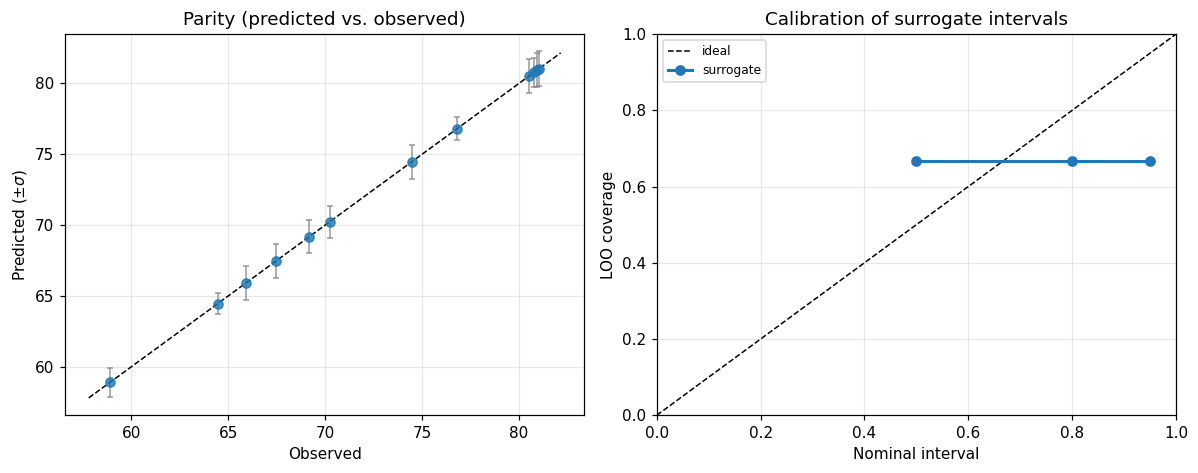

In [3]:
ini = ed.random_design(FACS, n=12, seed=3)
ini = ini.replace(model=MODELO)
y_ini = rendimiento(ini.matrix, seed=10)

sur0 = fit_surrogate(ini, y_ini, seed=0)   # GP (media a priori = OLS) si hay sklearn
cal = sur0.calibration()
print("Surrogate:", type(sur0).__name__)
print("Cobertura LOO de intervalos (nominal -> observada):")
for lvl, cov in cal["coverage"].items():
    print("  %.0f%% -> %.2f" % (lvl*100, cov))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4))
plotting.parity_plot(sur0, ax=a1)
plotting.calibration_plot(sur0, ax=a2)
plt.tight_layout(); plt.show()


El *parity plot* muestra las predicciones con barras ±σ; el *calibration plot*
compara la cobertura LOO contra lo nominal. Si los puntos caen bajo la diagonal, el
surrogate es **sobre-confiado** — y lo sabemos *antes* de confiar en su óptimo. Ése
es el moat: la caja es auditable.


## 3. Una oleada `intent="optimize"`: ¿dónde muestrear ahora?

Con el surrogate ajustado, pedimos la siguiente oleada por **Expected Improvement**.
`doekit` devuelve las corridas propuestas, el *best-so-far*, la mejora esperada y si
está **explorando o explotando**. Lo visualizamos: la superficie del surrogate μ(x)
(óptimo vs no-óptimos) y la superficie de adquisición (dónde el loop quiere ir).


Propose 4 run(s) by EI on a GPSurrogate (goal=max); best-so-far=81.05, top acquisition score=2.836. Balanced the region.

Corridas propuestas (unidades naturales):
 temp   pH  cat
56.33 8.75 0.16
59.75 5.79 0.47
59.71 7.40 0.37
57.81 8.77 0.18

Explora/explota: balanced (ratio σ=1.10)


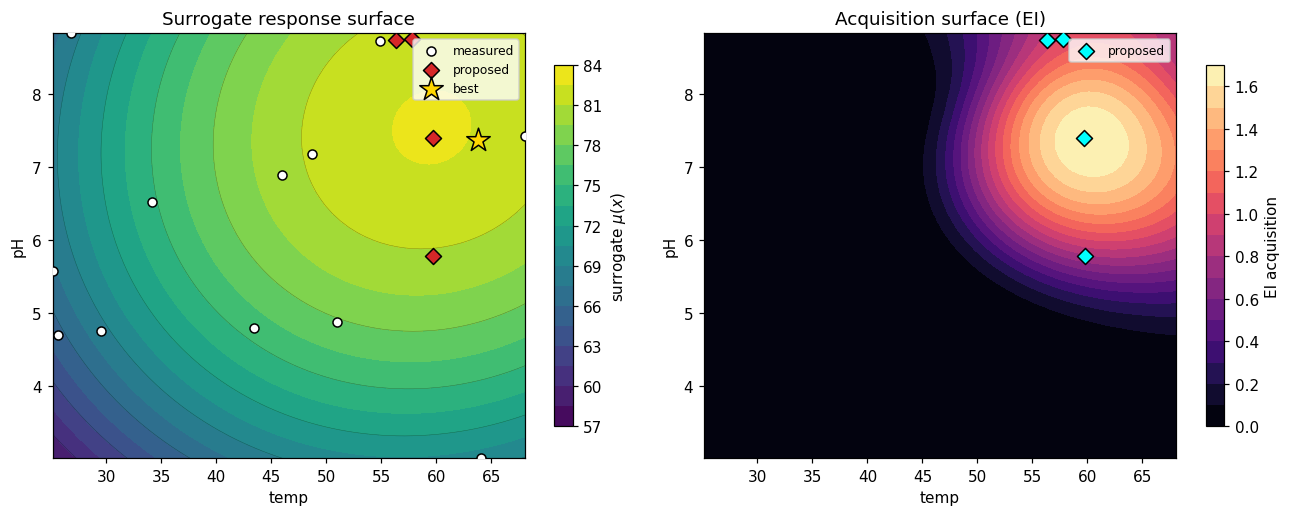

In [4]:
prop = ed.propose_next_runs(ini, response=y_ini, n_add=4, intent="optimize",
                            acquisition="ei", seed=1)
print(prop.rationale)
print("\nCorridas propuestas (unidades naturales):")
print(prop.added.matrix.round(2).to_string(index=False))
print("\nExplora/explota:", prop.explore_exploit["mode"],
      "(ratio σ=%.2f)" % prop.explore_exploit["ratio"])

# superficies en temp-pH, fijando cat en su óptimo
at = {"cat": OPT_NAT["cat"]}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
plotting.surrogate_surface(sur0, x="temp", y="pH", at=at, measured=ini.matrix,
                           proposed=prop.added.matrix,
                           optimum={"temp": OPT_NAT["temp"], "pH": OPT_NAT["pH"]}, ax=a1)
plotting.acquisition_plot(sur0, x="temp", y="pH", at=at, kind="ei",
                          proposed=prop.added.matrix, ax=a2)
plt.tight_layout(); plt.show()


## 4. Loop multi-generación: `optimize` vs `learn` vs `random`

Cerramos el loop varias oleadas con **el mismo presupuesto** para tres estrategias:

- **optimize** — surrogate + EI (mover el resultado),
- **learn** — augmentación D-óptima (afinar el modelo),
- **random** — muestreo aleatorio (baseline).

Medimos el *best-so-far* por generación y lo contrastamos con el óptimo real.


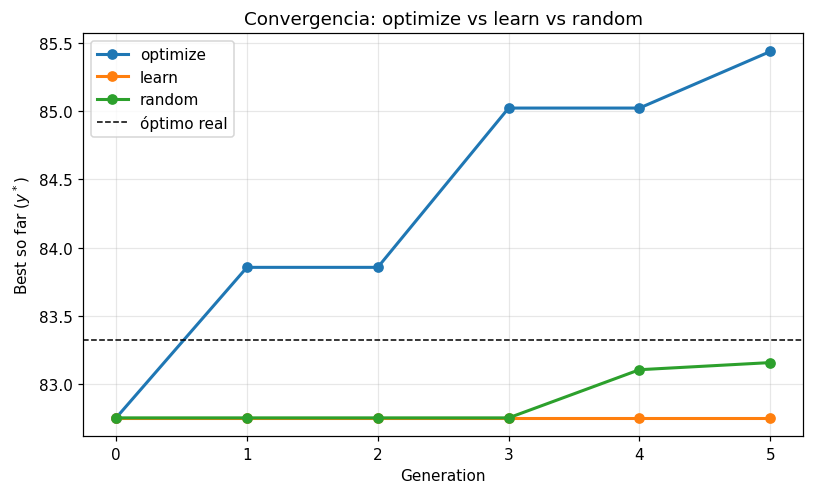

optimize  best-so-far final: 85.4 % (óptimo real 83.3 %)
learn     best-so-far final: 82.8 % (óptimo real 83.3 %)
random    best-so-far final: 83.2 % (óptimo real 83.3 %)


In [5]:
def corre_loop(modo, seed, generaciones=5, n_add=3):
    r = np.random.default_rng(seed)
    d0 = ed.random_design(FACS, n=12, seed=seed).replace(model=MODELO)
    frame = d0.matrix.copy()
    y = rendimiento(frame, seed=seed)
    hist = [float(np.max(y))]
    for g in range(generaciones):
        d = ed.Design(matrix=frame.copy(), factors=FACS, model=MODELO)
        if modo == "optimize":
            p = ed.propose_next_runs(d, response=y, n_add=n_add, intent="optimize",
                                     acquisition="ei", seed=seed+g)
            nuevos = p.added.matrix
        elif modo == "learn":
            p = ed.propose_next_runs(d, response=y, n_add=n_add, criterion="D",
                                     n_candidates=120, seed=seed+g)
            nuevos = p.added.matrix
        else:
            nuevos = pd.DataFrame({n: r.uniform(*activos[n], n_add) for n in activos})
        ynew = rendimiento(nuevos, seed=seed+100+g)
        frame = pd.concat([frame, nuevos], ignore_index=True)
        y = np.concatenate([y, ynew])
        hist.append(float(np.max(y)))
    return np.array(hist)

hist = {m: np.mean([corre_loop(m, s) for s in range(4)], axis=0)
        for m in ["optimize", "learn", "random"]}

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for m, c in [("optimize", "tab:red"), ("learn", "tab:blue"), ("random", "tab:gray")]:
    plotting.convergence_plot(hist[m], ax=ax, label=m)
ax.axhline(Y_OPT, color="black", linestyle="--", linewidth=1, label="óptimo real")
ax.legend(); ax.set_title("Convergencia: optimize vs learn vs random"); plt.tight_layout(); plt.show()

for m in hist:
    print("%-9s best-so-far final: %.1f %% (óptimo real %.1f %%)" % (m, hist[m][-1], Y_OPT))


A presupuesto igual, **optimize** sube más rápido hacia el óptimo real que
`learn` (que gasta corridas en precisión global) y que `random`. `learn` no está
"mal": responde a otra intención (afinar el modelo). El valor de `doekit` es que
**ambas viven en el mismo API** y son auditables con el mismo lenguaje de calidad.


## 5. Multi-objetivo: frente de Pareto (rendimiento vs costo)

Rara vez optimizamos una sola respuesta. Añadimos un **costo** (penaliza temperatura
y catalizador altos) y pedimos oleadas por **EHVI** (Expected Hypervolume
Improvement). El frente de Pareto muestra el *óptimo vs los no-óptimos*.


Propose 3 run(s) by EHVI on a GPSurrogate over 2 objectives ['rendimiento', 'ahorro']; best-so-far={'rendimiento': 79.30221112238962, 'ahorro': 1.34375027357814}. Exploiting the region.
Puntos en el frente de Pareto observado: 5


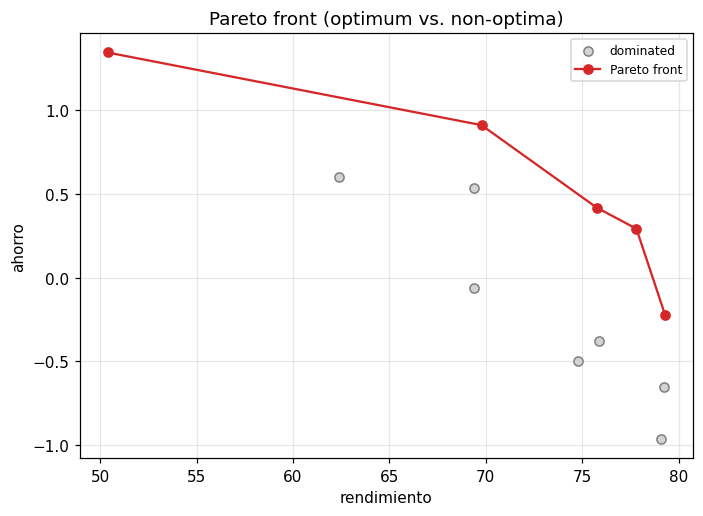

In [6]:
def costo(df):
    xT, xpH, xC = _codificar(df).T
    return -(0.6*xT + 0.8*xC)   # mayor = mejor (menos costo); se maximiza

ini2 = ed.random_design(FACS, n=12, seed=5).replace(model=MODELO)
Y2 = np.column_stack([rendimiento(ini2.matrix, seed=5), costo(ini2.matrix)])

prop_mo = ed.propose_next_runs(ini2, response=Y2, n_add=3, intent="optimize",
                               objectives=["rendimiento", "ahorro"],
                               goals={"rendimiento": "max", "ahorro": "max"},
                               n_candidates=80, seed=2)
print(prop_mo.rationale)
print("Puntos en el frente de Pareto observado:", len(prop_mo.pareto_front))

fig, ax = plt.subplots(figsize=(6.5, 4.8))
plotting.pareto_plot(pd.DataFrame(Y2, columns=["rendimiento", "ahorro"]),
                     goals={"rendimiento": "max", "ahorro": "max"}, ax=ax)
plt.tight_layout(); plt.show()


## 6. Veredicto

- El **surrogate** (GP con media a priori = la superficie OLS de doekit) predice
  con **σ(x) calibrada**: el *calibration plot* la audita — algo que una caja negra
  no entrega.
- `intent="optimize"` propone, oleada tras oleada, las corridas que **más acercan al
  óptimo real**, batiendo a `learn` y a `random` con el mismo presupuesto.
- El **multi-objetivo** (Pareto/EHVI) extiende la misma idea sin cambiar de sistema.
- El moat se conserva: **interpretabilidad** (tendencia polinómica) +
  **auditabilidad** (calibración) + el mismo **lenguaje de calidad** que `learn`.


## Puente: `Experiment` como generaciones (análogo a PDT)

El agregado `Experiment` ya modela *oleadas / generaciones*. `next(intent="optimize")`
cierra el loop de optimización dentro del mismo objeto trazable y serializable.


In [7]:
exp = ed.experiment(design=ini, model=MODELO, responses=["rendimiento"])
exp.ingest(y_ini)
nxt = exp.next(n_add=3, intent="optimize", acquisition="ei", seed=1)
print("intent:", nxt.intent, "| acquisition:", nxt.acquisition,
      "| best-so-far: %.1f %%" % nxt.best_so_far)
print("modo:", nxt.explore_exploit["mode"])
print("schema del snapshot:", exp.to_dict()["schema"])
print("schema de la propuesta:", nxt.to_dict()["schema"])


intent: optimize | acquisition: ei | best-so-far: 81.0 %
modo: exploring
schema del snapshot: doekit.Experiment/1


schema de la propuesta: doekit.NextRunsProposal/1
